# QTCAD M01 3D Poisson — Reference 로그 분석

이 노트북은 아래 QTCAD 예제 폴더에서 이미 실행 완료된 두 스크립트의 결과를
분석합니다.

`adaptive.py`와 `band_alignment.py`는 둘 다 `plt.show()`만 호출하고
`io.save()` / `plt.savefig()`는 호출하지 않으므로, `output/` 폴더에는
저장된 파일이 없습니다 (의도된 동작). 대신 각 스크립트를 실행할 때 콘솔
출력을 리다이렉트해 둔 `*_run.log` 파일에 mesh 통계, Poisson 반복 오차,
구속 에너지 준위, band offset 등 모든 정량적 결과가 그대로 남아 있으므로,
이 로그를 파싱해 분석합니다.

**Base directory**

`C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M01. 3D Poisson\Reference`

분석 대상:
- `adaptive_run.log` (`adaptive.py` 콘솔 출력 — 3D mesh 통계, 비선형
  Poisson 반복 오차/시간, adaptive mesh refinement 전후 비교)
- `band_alignment_run.log` (`band_alignment.py` 콘솔 출력 — GaAs/AlGaAs
  및 SiGe/Si/SiGe, SiGe/Ge/SiGe 이종접합의 1D 구속 에너지 준위, VBO/CBO,
  Ge 함량 스윕 결과)

---
## 📚 참고 문서
- **QTCAD 공식 튜토리얼** — Device 2: Poisson solver with adaptive meshing
  https://docs.nanoacademic.com/qtcad/tutorials/device/adaptive/
- **QTCAD 공식 튜토리얼** — Device 6: Band alignment in heterostructures
  https://docs.nanoacademic.com/qtcad/tutorials/device/band_alignment/
- **QTCAD 문서 포털**: https://docs.nanoacademic.com/qtcad/
- 소스 스크립트: `adaptive.py`, `band_alignment.py` (M01/Reference)
---


## 0. 두 소자의 스케매틱 + 핵심 물리 공식

**(a) adaptive.py**: 원통형 나노와이어(`nanowire_adaptive.geo`: 반지름 r0=1.5nm,
채널길이 L=10nm, source/drain 연장 Lc=5nm, 산화막 tox=1nm — M05의 nanowire.geo와
동일 설계).

**(b) band_alignment.py**: 1D 헤테로구조 스택(`band_alignment.geo`: left_barrier
10nm - well 20nm - right_barrier 10nm).

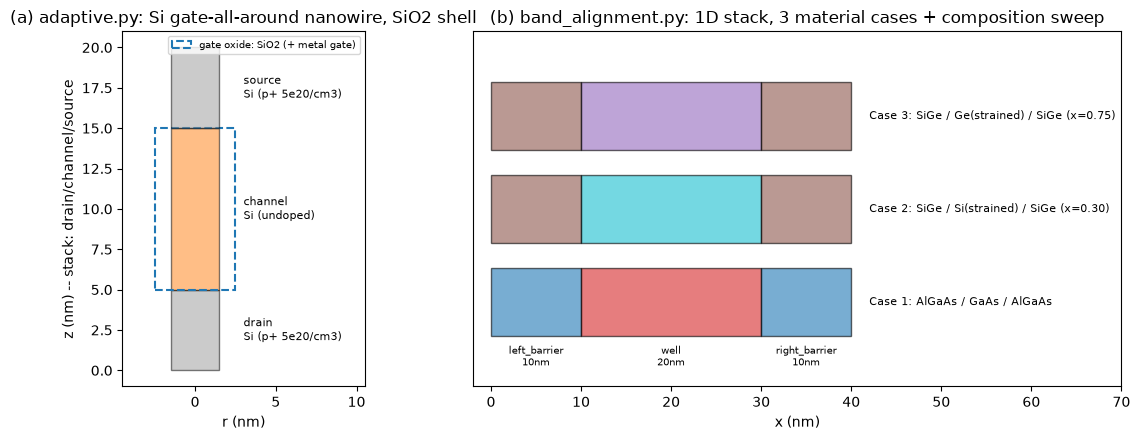

In [1]:
# [실험] 두 소자 스케매틱
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) nanowire -- materials from adaptive.py: new_region() calls
r0, L, Lc, tox = 1.5, 10.0, 5.0, 1.0
ax = axs[0]
z0 = 0
nw_layers = [("drain\nSi (p+ 5e20/cm3)", Lc, "0.6"), ("channel\nSi (undoped)", L, "tab:orange"),
            ("source\nSi (p+ 5e20/cm3)", Lc, "0.6")]
for name, h, color in nw_layers:
    ax.add_patch(mpatches.Rectangle((-r0, z0), 2*r0, h, fc=color, alpha=0.5, ec="k"))
    if "channel" in name:
        ax.add_patch(mpatches.Rectangle((-r0-tox, z0), 2*(r0+tox), h, fc="none", ec="tab:blue",
                                        ls="--", lw=1.5, label="gate oxide: SiO2 (+ metal gate)"))
    ax.text(r0 + tox + 0.5, z0 + h/2, name, va="center", fontsize=8)
    z0 += h
ax.set_xlim(-r0-tox-2, r0+tox+8); ax.set_ylim(-1, z0+1)
ax.set_aspect("equal"); ax.set_xlabel("r (nm)"); ax.set_ylabel("z (nm) -- stack: drain/channel/source")
ax.set_title("(a) adaptive.py: Si gate-all-around nanowire, SiO2 shell")
ax.legend(fontsize=7, loc="upper right")

# (b) band_alignment 1D stack -- 3 material cases tested in band_alignment.py (lines 27-29, 153-155, 187-189)
ax2 = axs[1]
cases = [
    ("Case 1: AlGaAs / GaAs / AlGaAs", "tab:blue", "tab:red"),
    ("Case 2: SiGe / Si(strained) / SiGe (x=0.30)", "tab:brown", "tab:cyan"),
    ("Case 3: SiGe / Ge(strained) / SiGe (x=0.75)", "tab:brown", "tab:purple"),
]
layer_names = ["left_barrier\n10nm", "well\n20nm", "right_barrier\n10nm"]
y_row = 0
for case_label, bcolor, wcolor in cases:
    x0 = 0
    colors = [bcolor, wcolor, bcolor]
    for name, thick, color in zip(layer_names, [10, 20, 10], colors):
        ax2.add_patch(mpatches.Rectangle((x0, y_row), thick, 0.8, fc=color, alpha=0.6, ec="k"))
        if y_row == 0:
            ax2.text(x0 + thick/2, -0.35, name, ha="center", fontsize=7)
        x0 += thick
    ax2.text(x0 + 2, y_row + 0.4, case_label, va="center", fontsize=8)
    y_row += 1.1
ax2.set_xlim(-2, x0 + 30); ax2.set_ylim(-0.6, y_row + 0.3)
ax2.set_yticks([]); ax2.set_xlabel("x (nm)")
ax2.set_title("(b) band_alignment.py: 1D stack, 3 material cases + composition sweep")
fig.tight_layout()
fig.savefig("device_schematics.png", dpi=150)
plt.show()


**물리 모델 — 비선형 Poisson 방정식**: `adaptive.py`가 적응 정제하며 푸는 방정식은
$$
\nabla \cdot \big(\varepsilon(\mathbf{r})\, \nabla \phi(\mathbf{r})\big) = -\rho(\mathbf{r}, \phi)
$$
($\rho$가 $\phi$ 자체에 의존 — 반도체의 캐리어 밀도가 Fermi-Dirac 분포를 통해
전위에 의존하므로 비선형). Newton/Gummel 반복으로 수렴시킵니다.

**물리 모델 — Band Alignment (band offset)**: 두 재질 경계에서 전도대/가전자대
불연속(CBO/VBO)은 재질의 전자친화도 $\chi$와 밴드갭 $E_g$로부터
$$
\Delta E_c = \chi_1 - \chi_2, \qquad \Delta E_v = (\chi_2+E_{g,2}) - (\chi_1+E_{g,1})
$$
로 계산됩니다. 합금(SiGe, AlGaAs)의 조성 $x$에 대한 의존성은 단순 선형보간이 아니라
**bowing parameter** $b$를 포함한 2차식
$$
P(x) = (1-x)P_A + xP_B - b\,x(1-x)
$$
($P$=밴드갭 등 물성치)을 따르는 것이 일반적이며, 아래 절에서 직선 참조선 대비
bowing 여부를 확인합니다.

In [2]:
# [동작] 기본 패키지 및 경로 설정
import re
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print  # fall back to plain print when run as a standalone script

BASE_DIR = Path.cwd()
EXPORT_DIR = BASE_DIR / "output" / "analysis_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

FILE_ADAPTIVE_LOG = BASE_DIR / "adaptive_run.log"
FILE_BAND_LOG = BASE_DIR / "band_alignment_run.log"

pd.set_option("display.float_format", lambda v: f"{v:.6g}")

In [3]:
# [점검] 파일 inventory
expected_files = {
    "adaptive_run.log": FILE_ADAPTIVE_LOG,
    "band_alignment_run.log": FILE_BAND_LOG,
}

inventory_df = pd.DataFrame(
    [
        {
            "file": name,
            "exists": path.exists(),
            "size_KB": round(path.stat().st_size / 1024, 1) if path.exists() else None,
        }
        for name, path in expected_files.items()
    ]
)
display(inventory_df)

output_dir = BASE_DIR / "output"
saved_outputs = list(output_dir.glob("*")) if output_dir.exists() else []
print(f"output/ 폴더 내 저장된 파일 수: {len(saved_outputs)} "
      f"(0이면 예상대로 — 두 스크립트 모두 plt.show()만 호출, 저장 없음)")

,file,exists,size_KB
0,adaptive_run.log,True,7.3
1,band_alignment_run.log,True,5.8


output/ 폴더 내 저장된 파일 수: 1 (0이면 예상대로 — 두 스크립트 모두 plt.show()만 호출, 저장 없음)


## 1. `adaptive.py` — Adaptive mesh 통계 & Poisson 수렴

게이트 전압 2V가 인가된 나노와이어 트랜지스터에서 비선형 Poisson 방정식을
풀며, 반복 중 오차가 정체되면 mesh를 자동으로 refine하는 스크립트입니다.
로그에는 refine 전/후 mesh 통계와, 매 Poisson 반복의 최대 절대 오차(V) /
계산 시간(s)이 표로 출력되어 있습니다.

In [4]:
# [동작] adaptive_run.log 읽기 및 mesh 통계 파싱
adaptive_log = FILE_ADAPTIVE_LOG.read_text(encoding="utf-8", errors="replace")

node_counts = [int(x) for x in re.findall(r"Total number of nodes\s+(\d+)", adaptive_log)]
elem_counts = [int(x) for x in re.findall(r"Total number of elements\s+(\d+)", adaptive_log)]
tet_counts = [int(x) for x in re.findall(r"Tetrahedral elements\s+(\d+)", adaptive_log)]

mesh_stage_df = pd.DataFrame(
    {
        "stage": ["coarse (initial)", "refined (after refinement)"],
        "nodes": node_counts,
        "elements": elem_counts,
        "tetrahedra": tet_counts,
    }
)
mesh_stage_df["node_growth_x"] = mesh_stage_df["nodes"] / mesh_stage_df["nodes"].iloc[0]
mesh_stage_df["element_growth_x"] = mesh_stage_df["elements"] / mesh_stage_df["elements"].iloc[0]
mesh_stage_df.to_csv(EXPORT_DIR / "adaptive_mesh_stage.csv", index=False)
display(mesh_stage_df)

,stage,nodes,elements,tetrahedra,node_growth_x,element_growth_x
0,coarse (initial),865,4059,3579,1,1
1,refined (after refinement),19824,110445,104977,22.9179,27.2099


In [5]:
# [동작] Poisson 반복 테이블 파싱 (coarse + refined 두 단계 모두 포함)
iter_rows = re.findall(
    r"^\s*(\d+)\s+([\d.eE+-]+)\s+([\d.]+)\s+\(([^)]+)\)",
    adaptive_log,
    flags=re.MULTILINE,
)
poisson_df = pd.DataFrame(iter_rows, columns=["iter", "max_abs_error_V", "time_s", "max_err_coords_m"])
poisson_df["iter"] = poisson_df["iter"].astype(int)
poisson_df["max_abs_error_V"] = poisson_df["max_abs_error_V"].astype(float)
poisson_df["time_s"] = poisson_df["time_s"].astype(float)

# 로그 상 iteration 15에서 오차가 정체(saturate)되어 refine이 발생함
refine_idx = 15
poisson_df["mesh_stage"] = np.where(
    poisson_df["iter"] <= refine_idx, "coarse", "refined"
)
poisson_df.to_csv(EXPORT_DIR / "adaptive_poisson_iterations.csv", index=False)
display(poisson_df)

,iter,max_abs_error_V,time_s,max_err_coords_m,mesh_stage
0,1,2.64,15.3017,"-2.500e-09, 0.000e+00, 5.000e-09",coarse
1,2,0.9722,3.83751,"-7.537e-12, 7.537e-12, 1.026e-08",coarse
2,3,0.289,3.5338,"-7.537e-12, 7.537e-12, 1.026e-08",coarse
3,4,0.02029,4.36152,"-1.293e-10, -6.957e-11, 1.367e-08",coarse
4,5,0.009281,3.89437,"-4.736e-10, -1.284e-10, 7.293e-09",coarse
5,6,0.009158,3.64627,"0.000e+00, 2.220e-25, 1.217e-08",coarse
6,7,0.01132,2.74025,"0.000e+00, 2.220e-25, 1.217e-08",coarse
7,8,0.01135,3.71492,"0.000e+00, 2.220e-25, 1.217e-08",coarse
8,9,0.01144,2.69262,"0.000e+00, 2.220e-25, 1.217e-08",coarse
9,10,0.0115,2.27933,"0.000e+00, 2.220e-25, 1.217e-08",coarse


In [6]:
# [점검] refine 전/후 수렴 통계 비교
conv_match = re.search(
    r"Error converged below required tolerance after:\s*\n>\s*(\d+) Poisson iterations\.\s*\n"
    r">\s*([\d.]+) s\.\s*\nAverage computation time / Poisson iteration is ([\d.]+) s",
    adaptive_log,
)
total_time_match = re.search(r"Total simulation time: ([\d.]+) s", adaptive_log)

n_total_iters, refined_stage_time_str, avg_time_refined_str = conv_match.groups()
total_sim_time = float(total_time_match.group(1))
refined_stage_time = float(refined_stage_time_str)
coarse_stage_time = poisson_df.loc[poisson_df["mesh_stage"] == "coarse", "time_s"].sum()

stage_summary_df = pd.DataFrame(
    {
        "stage": ["coarse", "refined"],
        "n_iterations": [refine_idx, int(n_total_iters) - refine_idx],
        "final_error_V": [
            poisson_df.loc[poisson_df["mesh_stage"] == "coarse", "max_abs_error_V"].iloc[-1],
            poisson_df.loc[poisson_df["mesh_stage"] == "refined", "max_abs_error_V"].iloc[-1],
        ],
        "wall_time_s": [coarse_stage_time, refined_stage_time],
        "time_fraction": [coarse_stage_time / total_sim_time, refined_stage_time / total_sim_time],
    }
)
stage_summary_df.to_csv(EXPORT_DIR / "adaptive_stage_summary.csv", index=False)
display(stage_summary_df)
print(f"Total simulation time: {total_sim_time:.1f} s")

,stage,n_iterations,final_error_V,wall_time_s,time_fraction
0,coarse,15,0.01164,53.8773,0.192303
1,refined,6,8.707e-07,195.404,0.697449


Total simulation time: 280.2 s


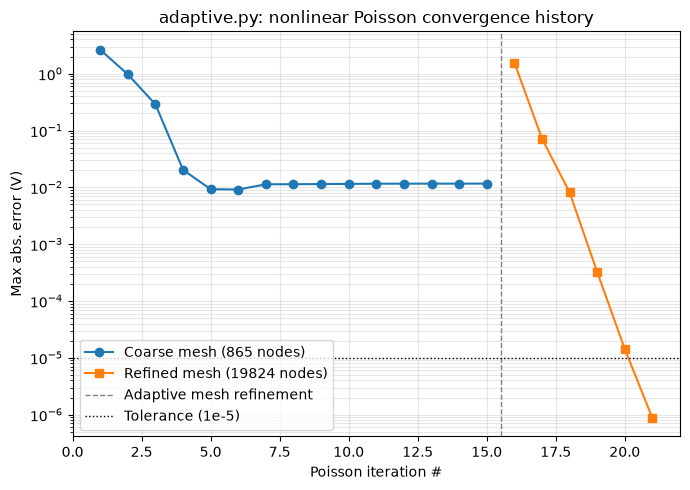

In [7]:
# [실험] Poisson 오차 수렴 이력 (coarse -> refined, log scale)
fig, ax = plt.subplots(figsize=(7, 5))
coarse_mask = poisson_df["mesh_stage"] == "coarse"
ax.semilogy(poisson_df.loc[coarse_mask, "iter"], poisson_df.loc[coarse_mask, "max_abs_error_V"],
            "o-", color="C0", label=f"Coarse mesh ({node_counts[0]} nodes)")
ax.semilogy(poisson_df.loc[~coarse_mask, "iter"], poisson_df.loc[~coarse_mask, "max_abs_error_V"],
            "s-", color="C1", label=f"Refined mesh ({node_counts[1]} nodes)")
ax.axvline(refine_idx + 0.5, color="gray", linestyle="--", linewidth=1, label="Adaptive mesh refinement")
ax.axhline(1e-5, color="k", linestyle=":", linewidth=1, label="Tolerance (1e-5)")
ax.set_xlabel("Poisson iteration #")
ax.set_ylabel("Max abs. error (V)")
ax.set_title("adaptive.py: nonlinear Poisson convergence history")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
fig.savefig(EXPORT_DIR / "adaptive_poisson_convergence.png", dpi=150)
plt.show()

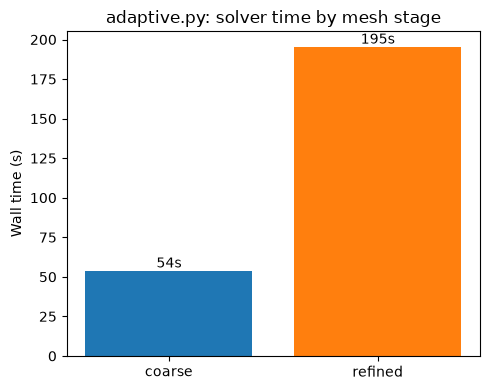

In [8]:
# [실험] Mesh 단계별 solver 소요 시간
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(stage_summary_df["stage"], stage_summary_df["wall_time_s"], color=["C0", "C1"])
ax.set_ylabel("Wall time (s)")
ax.set_title("adaptive.py: solver time by mesh stage")
for i, v in enumerate(stage_summary_df["wall_time_s"]):
    ax.text(i, v + 2, f"{v:.0f}s", ha="center")
plt.tight_layout()
fig.savefig(EXPORT_DIR / "adaptive_stage_time.png", dpi=150)
plt.show()

**해석:** coarse mesh에서는 오차가 ~1e-2 V 부근에서 정체된다 — 이는 Newton/
Gummel 반복을 아무리 더 돌려도 coarse mesh 자체의 discretization 오차보다
아래로는 내려갈 수 없기 때문이다. Mesh를 refine한 뒤에는 오차가 네 자릿수
가까이 떨어져 tolerance(1e-5) 아래로 수렴한다. Refined mesh는 노드 수가
~23배 많음에도 coarse mesh 해를 보간해 시작하기 때문에 6번 반복만으로
수렴하며(coarse는 15번), 이는 adaptive meshing의 실질적 이점을 보여준다:
저렴한 coarse mesh에서 대부분 수렴시키고, 비싼 fine mesh는 답을 다듬는
데만 쓴다.

## 2. `band_alignment.py` — 1D 구속 에너지 & 밴드 오프셋

GaAs/AlGaAs 및 SiGe/Si(Ge)/SiGe 이종접합에서 Anderson's rule과 RESCU 정합
파라미터로 band alignment를 수행하고, 1D Schrödinger 솔버로 양자우물의
구속 에너지 준위를 계산하는 스크립트입니다.

In [9]:
# [동작] band_alignment_run.log 읽기 및 구속 에너지 준위 파싱
band_log = FILE_BAND_LOG.read_text(encoding="utf-8", errors="replace")

energy_blocks = re.findall(r"Energy levels \(eV\)\s*\n(\[[^\]]*\])", band_log)
energies_before = np.array([float(x) for x in energy_blocks[0].strip("[]").split()])
energies_after = np.array([float(x) for x in energy_blocks[1].strip("[]").split()])

levels_df = pd.DataFrame(
    {
        "level": np.arange(1, len(energies_before) + 1),
        "E_before_shift_eV": energies_before,
        "E_after_minus0p5eV_shift_eV": energies_after,
    }
)
levels_df["shift_eV"] = levels_df["E_before_shift_eV"] - levels_df["E_after_minus0p5eV_shift_eV"]
levels_df.to_csv(EXPORT_DIR / "band_alignment_levels.csv", index=False)
display(levels_df)

,level,E_before_shift_eV,E_after_minus0p5eV_shift_eV,shift_eV
0,1,0.769977,0.271177,0.498799
1,2,0.801314,0.306185,0.495129
2,3,0.853134,0.364436,0.488698
3,4,0.924338,0.445747,0.478591
4,5,1.011,0.549751,0.461244
5,6,1.06706,0.675699,0.391363
6,7,1.07138,0.821862,0.249515
7,8,1.10643,0.982545,0.123886
8,9,1.14912,1.06856,0.080557
9,10,1.17786,1.07128,0.106583


In [10]:
# [점검] shift가 강체 이동(rigid shift)인지 정량 확인
print(f"Nominal well shift applied     : 0.500 eV")
print(f"Mean per-level shift           : {levels_df['shift_eV'].mean():.4f} eV")
print(f"Std. dev. of per-level shift   : {levels_df['shift_eV'].std():.4f} eV")
print(f"Level with largest shift       : level {levels_df.loc[levels_df['shift_eV'].idxmax(), 'level']} "
      f"({levels_df['shift_eV'].max():.4f} eV)")
print(f"Level with smallest shift      : level {levels_df.loc[levels_df['shift_eV'].idxmin(), 'level']} "
      f"({levels_df['shift_eV'].min():.4f} eV)")

Nominal well shift applied     : 0.500 eV
Mean per-level shift           : 0.3374 eV
Std. dev. of per-level shift   : 0.1778 eV
Level with largest shift       : level 1 (0.4988 eV)
Level with smallest shift      : level 9 (0.0806 eV)


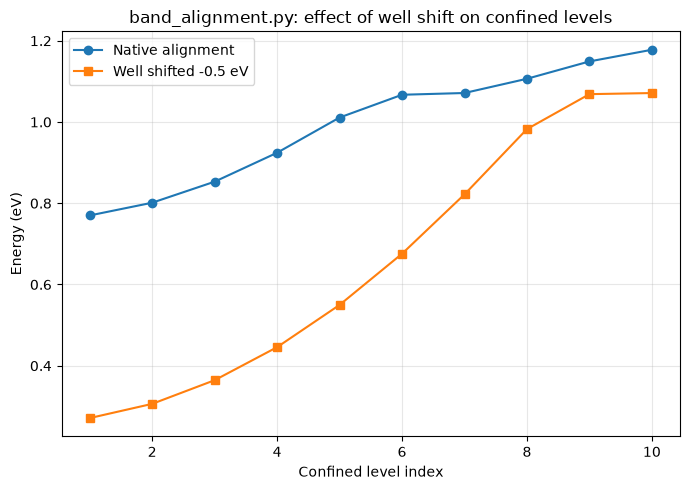

In [11]:
# [실험] Well shift 전/후 구속 에너지 준위 비교
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(levels_df["level"], levels_df["E_before_shift_eV"], "o-", label="Native alignment")
ax.plot(levels_df["level"], levels_df["E_after_minus0p5eV_shift_eV"], "s-", label="Well shifted -0.5 eV")
ax.set_xlabel("Confined level index")
ax.set_ylabel("Energy (eV)")
ax.set_title("band_alignment.py: effect of well shift on confined levels")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(EXPORT_DIR / "band_alignment_well_shift.png", dpi=150)
plt.show()

**해석:** shift는 균일한 강체 이동이 아니다. 가장 낮은 4개 준위는 0.48~0.50 eV
만큼 이동해 명목값 0.5 eV를 거의 그대로 따라가는데, 이는 이 상태들이
우물(well) 내부에 거의 완전히 국한되어 있어 우물 기준 전위의 이동을
그대로 따라가기 때문이다. 5번째 준위부터는 이동량이 빠르게 줄어들고
(0.46, 0.39, 0.25 eV, ...) 마지막 준위에서는 비단조적으로(0.08 → 0.11 eV)
변한다. 이는 높은 준위일수록 (이동하지 않은) AlGaAs barrier 영역으로
파동함수가 점점 더 퍼져 나가, 에너지가 우물 전위와 barrier 전위의 혼합으로
결정되기 때문이며, 마지막 준위의 비단조적 변화는 우물을 더 깊게 만들면서
barrier 쪽 상태와 well 쪽 상태의 순서가 뒤바뀌는(level crossing) 효과로
볼 수 있다. 실무적으로는 유한 우물의 바닥 몇 개 준위만 "기준 전위 이동을
그대로 따라간다"고 근사할 수 있고, 더 높은 준위에는 이 근사가 적용되지
않는다.

In [12]:
# [동작] SiGe/Si/SiGe, SiGe/Ge/SiGe 밴드 오프셋 파싱
hetero_rows = re.findall(
    r"(\S+) heterostructure: VBO = ([\d.]+) eV \| CBO = ([\d.]+) eV", band_log
)
hetero_df = pd.DataFrame(hetero_rows, columns=["heterostructure", "VBO_eV", "CBO_eV"])
hetero_df["VBO_eV"] = hetero_df["VBO_eV"].astype(float)
hetero_df["CBO_eV"] = hetero_df["CBO_eV"].astype(float)
hetero_df["CBO_over_VBO"] = hetero_df["CBO_eV"] / hetero_df["VBO_eV"]
hetero_df.to_csv(EXPORT_DIR / "band_offsets.csv", index=False)
display(hetero_df)

,heterostructure,VBO_eV,CBO_eV,CBO_over_VBO
0,SiGe/Si/SiGe,0.057937,0.169713,2.92927
1,SiGe/Ge/SiGe,0.176095,0.142431,0.80883


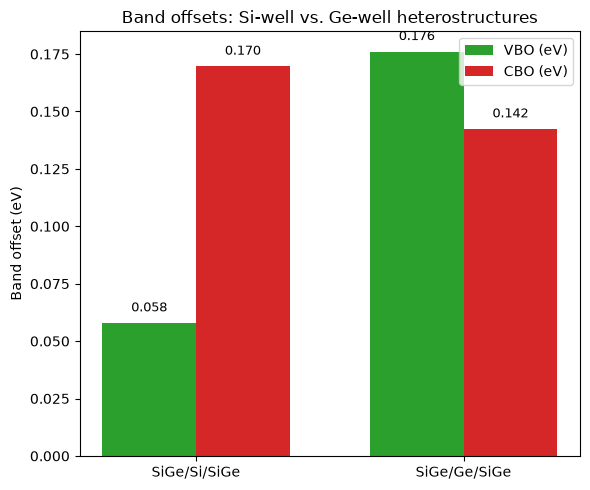

In [13]:
# [실험] VBO/CBO 비교: Si-well vs. Ge-well
fig, ax = plt.subplots(figsize=(6, 5))
x = np.arange(len(hetero_df))
width = 0.35
ax.bar(x - width / 2, hetero_df["VBO_eV"], width, label="VBO (eV)", color="C2")
ax.bar(x + width / 2, hetero_df["CBO_eV"], width, label="CBO (eV)", color="C3")
ax.set_xticks(x)
ax.set_xticklabels(hetero_df["heterostructure"])
ax.set_ylabel("Band offset (eV)")
ax.set_title("Band offsets: Si-well vs. Ge-well heterostructures")
ax.legend()
for i in range(len(hetero_df)):
    ax.text(i - width / 2, hetero_df["VBO_eV"].iloc[i] + 0.005, f"{hetero_df['VBO_eV'].iloc[i]:.3f}",
            ha="center", fontsize=9)
    ax.text(i + width / 2, hetero_df["CBO_eV"].iloc[i] + 0.005, f"{hetero_df['CBO_eV'].iloc[i]:.3f}",
            ha="center", fontsize=9)
plt.tight_layout()
fig.savefig(EXPORT_DIR / "band_offsets_comparison.png", dpi=150)
plt.show()

**해석:** SiGe/Si/SiGe는 CBO(0.170 eV)가 VBO(0.058 eV)의 약 3배로,
전자가 정공보다 훨씬 깊은 우물을 보게 되어 전자 스핀 큐비트 스택으로 쓰이는
이유를 설명한다. SiGe/Ge/SiGe는 반대로 VBO(0.176 eV)가 CBO(0.142 eV)보다
커서 정공(hole) 스핀 큐비트에 적합하다. 두 경우 모두 barrier는 SiGe
합금이며 Ge 함량(30% vs. 75%)만 다르므로, 구속 특성의 방향을 결정하는
것은 barrier 조성 자체가 아니라 우물에 어떤 물질(Si 또는 Ge)이 들어가는가
이다.

In [14]:
# [동작] Ge 함량(x=0~0.8) 스윕 테이블 파싱 (SiGe/Si/SiGe)
table_match = re.search(
    r"-{10,}\s*\n\s*x\s+VBO \(eV\)\s+CBO \(eV\)\s*\n-{10,}\s*\n(.*?)\n\n",
    band_log,
    flags=re.DOTALL,
)
sweep_rows = re.findall(r"^\s*([\d.]+)\s+([\d.]+)\s+([\d.]+)\s*$", table_match.group(1), flags=re.MULTILINE)
sweep_df = pd.DataFrame(sweep_rows, columns=["x_Ge_fraction", "VBO_eV", "CBO_eV"]).astype(float)

# 선형(Vegard's law 식) 참조선 대비 편차(bowing) 계산
linear_vbo = sweep_df["VBO_eV"].iloc[0] + (sweep_df["VBO_eV"].iloc[-1] - sweep_df["VBO_eV"].iloc[0]) * (
    sweep_df["x_Ge_fraction"] - sweep_df["x_Ge_fraction"].iloc[0]
) / (sweep_df["x_Ge_fraction"].iloc[-1] - sweep_df["x_Ge_fraction"].iloc[0])
linear_cbo = sweep_df["CBO_eV"].iloc[0] + (sweep_df["CBO_eV"].iloc[-1] - sweep_df["CBO_eV"].iloc[0]) * (
    sweep_df["x_Ge_fraction"] - sweep_df["x_Ge_fraction"].iloc[0]
) / (sweep_df["x_Ge_fraction"].iloc[-1] - sweep_df["x_Ge_fraction"].iloc[0])

sweep_df["VBO_linear_ref_eV"] = linear_vbo
sweep_df["CBO_linear_ref_eV"] = linear_cbo
sweep_df["VBO_bowing_meV"] = (sweep_df["VBO_eV"] - linear_vbo) * 1e3
sweep_df["CBO_bowing_meV"] = (sweep_df["CBO_eV"] - linear_cbo) * 1e3
sweep_df.to_csv(EXPORT_DIR / "ge_sweep_bowing.csv", index=False)
display(sweep_df)

,x_Ge_fraction,VBO_eV,CBO_eV,VBO_linear_ref_eV,CBO_linear_ref_eV,VBO_bowing_meV,CBO_bowing_meV
0,0,0,0,0,0,0,0
1,0.05,0.009175,0.027031,0.0106182,0.0307951,-1.44319,-3.76412
2,0.1,0.018543,0.054562,0.0212364,0.0615902,-2.69337,-7.02825
3,0.15,0.028102,0.082598,0.0318546,0.0923854,-3.75256,-9.78737
4,0.2,0.037855,0.111133,0.0424727,0.12318,-4.61775,-12.0475
5,0.25,0.0478,0.140172,0.0530909,0.153976,-5.29094,-13.8036
6,0.3,0.057937,0.169713,0.0637091,0.184771,-5.77212,-15.0577
7,0.35,0.068267,0.199754,0.0743273,0.215566,-6.06031,-15.8119
8,0.4,0.078789,0.230298,0.0849455,0.246361,-6.1565,-16.063
9,0.45,0.089503,0.261345,0.0955637,0.277156,-6.06069,-15.8111


In [15]:
# [점검] 최대 bowing 크기와 위치
max_vbo_bow_idx = sweep_df["VBO_bowing_meV"].abs().idxmax()
max_cbo_bow_idx = sweep_df["CBO_bowing_meV"].abs().idxmax()
print(f"Max VBO deviation from linear: {sweep_df.loc[max_vbo_bow_idx, 'VBO_bowing_meV']:.2f} meV "
      f"at x={sweep_df.loc[max_vbo_bow_idx, 'x_Ge_fraction']:.2f}")
print(f"Max CBO deviation from linear: {sweep_df.loc[max_cbo_bow_idx, 'CBO_bowing_meV']:.2f} meV "
      f"at x={sweep_df.loc[max_cbo_bow_idx, 'x_Ge_fraction']:.2f}")

Max VBO deviation from linear: -6.16 meV at x=0.40
Max CBO deviation from linear: -16.06 meV at x=0.40


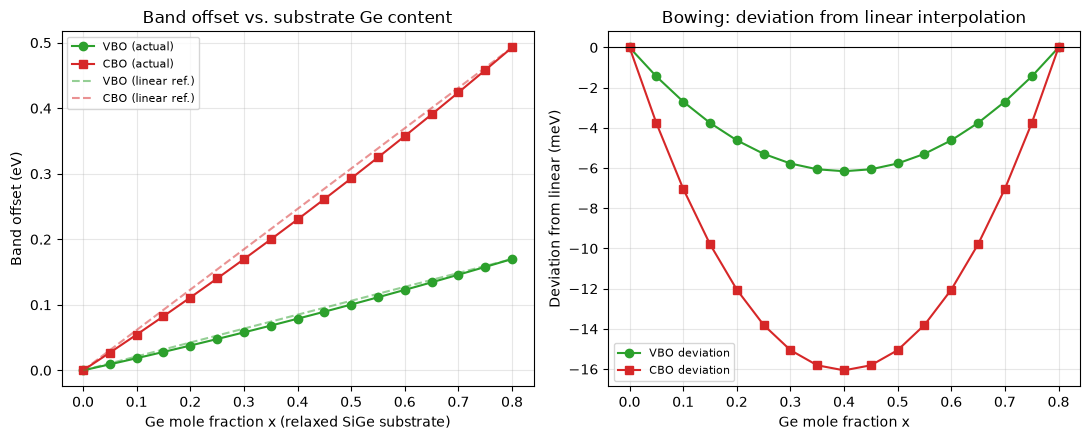

In [16]:
# [실험] Band offset vs. Ge 함량, 그리고 선형 참조 대비 bowing
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(sweep_df["x_Ge_fraction"], sweep_df["VBO_eV"], "o-", label="VBO (actual)", color="C2")
axes[0].plot(sweep_df["x_Ge_fraction"], sweep_df["CBO_eV"], "s-", label="CBO (actual)", color="C3")
axes[0].plot(sweep_df["x_Ge_fraction"], sweep_df["VBO_linear_ref_eV"], "--", color="C2", alpha=0.5,
             label="VBO (linear ref.)")
axes[0].plot(sweep_df["x_Ge_fraction"], sweep_df["CBO_linear_ref_eV"], "--", color="C3", alpha=0.5,
             label="CBO (linear ref.)")
axes[0].set_xlabel("Ge mole fraction x (relaxed SiGe substrate)")
axes[0].set_ylabel("Band offset (eV)")
axes[0].set_title("Band offset vs. substrate Ge content")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(sweep_df["x_Ge_fraction"], sweep_df["VBO_bowing_meV"], "o-", color="C2", label="VBO deviation")
axes[1].plot(sweep_df["x_Ge_fraction"], sweep_df["CBO_bowing_meV"], "s-", color="C3", label="CBO deviation")
axes[1].axhline(0, color="k", linewidth=0.8)
axes[1].set_xlabel("Ge mole fraction x")
axes[1].set_ylabel("Deviation from linear (meV)")
axes[1].set_title("Bowing: deviation from linear interpolation")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(EXPORT_DIR / "ge_sweep_bowing.png", dpi=150)
plt.show()

**해석:** VBO(x)와 CBO(x) 모두 x=0~0.8 사이 직선 참조선보다 아래로
(음의 방향으로) bowing되며, 중간 조성(x≈0.4) 부근에서 편차가 VBO는
약 -6 meV, CBO는 약 -16 meV로 최대가 된다. 이 "아래로 처지는" 형태는
반도체 합금에서 흔히 보는 표준적인 bowing 방향과 일치하며 (bowing
parameter b>0인 2차 보간, E(x) = (1-x)E_A + x E_B − b·x(1-x) 형태),
SiGe/Si/SiGe 계에서 strain과 band parameter의 조성 의존성이 단순 선형이
아님을 보여준다. Virtual substrate의 Ge 함량을 골라 원하는 구속 깊이를
설계할 때, 선형(Vegard's law) 근사만 쓰면 이 bowing 만큼 체계적으로
실제보다 큰 offset 값을 얻게 된다는 뜻이다 (CBO 쪽이 VBO보다 약 2.6배
더 크게 bowing되어 영향이 더 크다).

## 3. 최종 요약

In [17]:
# [점검] 핵심 결과 요약
print("=" * 88)
print("QTCAD M01 3D POISSON — REFERENCE LOG ANALYSIS SUMMARY")
print("=" * 88)
print(f"[adaptive.py] Mesh nodes: {node_counts[0]} -> {node_counts[1]} "
      f"({mesh_stage_df['node_growth_x'].iloc[1]:.1f}x growth)")
print(f"[adaptive.py] Poisson error: {poisson_df['max_abs_error_V'].iloc[0]:.3e} V (iter 1) "
      f"-> {poisson_df['max_abs_error_V'].iloc[-1]:.3e} V (iter {int(n_total_iters)}, converged)")
print(f"[adaptive.py] Total iterations: {n_total_iters}, total wall time: {total_sim_time:.1f} s")
print(f"[band_alignment.py] -0.5 eV well shift -> mean level shift "
      f"{levels_df['shift_eV'].mean():.3f} eV (std {levels_df['shift_eV'].std():.3f} eV, non-rigid)")
print(f"[band_alignment.py] SiGe/Si/SiGe: VBO={hetero_df['VBO_eV'].iloc[0]:.4f} eV, "
      f"CBO={hetero_df['CBO_eV'].iloc[0]:.4f} eV (electron-confining)")
print(f"[band_alignment.py] SiGe/Ge/SiGe: VBO={hetero_df['VBO_eV'].iloc[1]:.4f} eV, "
      f"CBO={hetero_df['CBO_eV'].iloc[1]:.4f} eV (hole-confining)")
print(f"[band_alignment.py] Ge-content sweep: max bowing "
      f"{sweep_df['VBO_bowing_meV'].abs().max():.1f} meV (VBO), "
      f"{sweep_df['CBO_bowing_meV'].abs().max():.1f} meV (CBO)")
print("=" * 88)

QTCAD M01 3D POISSON — REFERENCE LOG ANALYSIS SUMMARY
[adaptive.py] Mesh nodes: 865 -> 19824 (22.9x growth)
[adaptive.py] Poisson error: 2.640e+00 V (iter 1) -> 8.707e-07 V (iter 21, converged)
[adaptive.py] Total iterations: 21, total wall time: 280.2 s
[band_alignment.py] -0.5 eV well shift -> mean level shift 0.337 eV (std 0.178 eV, non-rigid)
[band_alignment.py] SiGe/Si/SiGe: VBO=0.0579 eV, CBO=0.1697 eV (electron-confining)
[band_alignment.py] SiGe/Ge/SiGe: VBO=0.1761 eV, CBO=0.1424 eV (hole-confining)
[band_alignment.py] Ge-content sweep: max bowing 6.2 meV (VBO), 16.1 meV (CBO)


## 해석 주의사항

- 이 노트북의 모든 수치는 `output/`에 저장된 필드/메시 데이터가 아니라,
  `*_run.log`에 출력된 콘솔 텍스트를 파싱한 값입니다. 두 스크립트
  (`adaptive.py`, `band_alignment.py`)는 `plt.show()`만 호출하므로 실제
  포텐셜 φ(r)이나 파동함수 값 자체는 디스크에 남아있지 않습니다.
- `Max abs error (V)`는 Poisson 솔버의 Newton/Gummel 반복 사이 전위
  최대 변화량이며, 절대 오차가 아니라 반복 간 수렴 지표입니다.
- 1D 구속 에너지 준위의 "shift"는 강체 이동이 아닙니다. 낮은 준위일수록
  우물 전위 이동을 거의 그대로 따라가고, 높은 준위일수록 barrier 영역의
  (이동하지 않은) 전위 영향을 더 많이 받습니다. 준위 index가 이동 전/후에
  물리적으로 동일한 상태를 가리키지 않을 수 있습니다 (level crossing 가능).
- VBO/CBO는 RESCU 정합 파라미터(`align_bands`)에 기반한 값이며, 온도나
  strain 세부 모델에 따라 실제 실험값과 차이가 있을 수 있습니다.
- Ge 함량 스윕의 "bowing"은 여기서 정의한 두 끝점(x=0, x=0.8) 사이 직선
  참조선 대비 편차이며, 물성 문헌에서 사용하는 표준 bowing parameter
  (2차 다항식 계수)와는 정의가 다를 수 있습니다.